# Stage 7: Error Analysis

Run this after `python -m src.train` and `python -m src.evaluate` have produced
`models/best_model.pt`. This notebook inspects actual test-set predictions and
buckets them into correct-real, correct-fake, false positive, and false negative,
so you can look at real examples instead of just reading a single accuracy number.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import torch
from PIL import Image

sys.path.append('..')
from src.model import load_model
from src.dataset import FaceDataset
from src.preprocessing import get_eval_transforms

PLOTS_DIR = '../results/plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = load_model('../models/best_model.pt', device)
test_ds = FaceDataset('../data/processed/test', transform=get_eval_transforms())
print(f'Test set size: {len(test_ds)}')

Test set size: 438


In [2]:
buckets = {'correct_real': [], 'correct_fake': [], 'false_positive': [], 'false_negative': []}

with torch.no_grad():
    for path, true_label in test_ds.samples:
        image = Image.open(path).convert('RGB')
        tensor = get_eval_transforms()(image).unsqueeze(0).to(device)
        prob = torch.sigmoid(model(tensor)).item()
        pred_label = 1 if prob >= 0.5 else 0

        if true_label == 0 and pred_label == 0:
            buckets['correct_real'].append((path, prob))
        elif true_label == 1 and pred_label == 1:
            buckets['correct_fake'].append((path, prob))
        elif true_label == 0 and pred_label == 1:
            buckets['false_positive'].append((path, prob))  # real predicted as manipulated
        elif true_label == 1 and pred_label == 0:
            buckets['false_negative'].append((path, prob))  # manipulated predicted as real

for name, items in buckets.items():
    print(f'{name}: {len(items)}')

correct_real: 186
correct_fake: 213
false_positive: 29
false_negative: 10


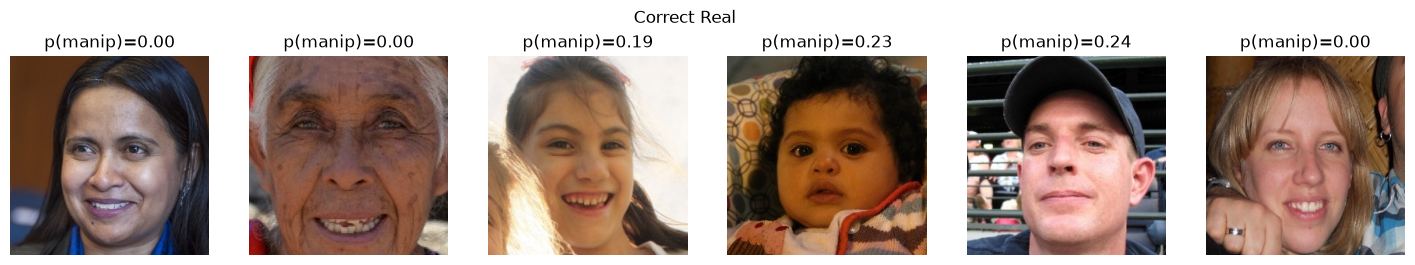

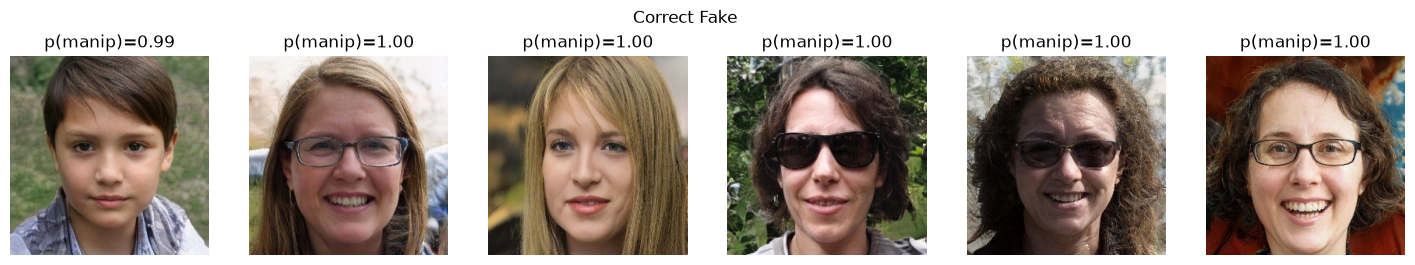

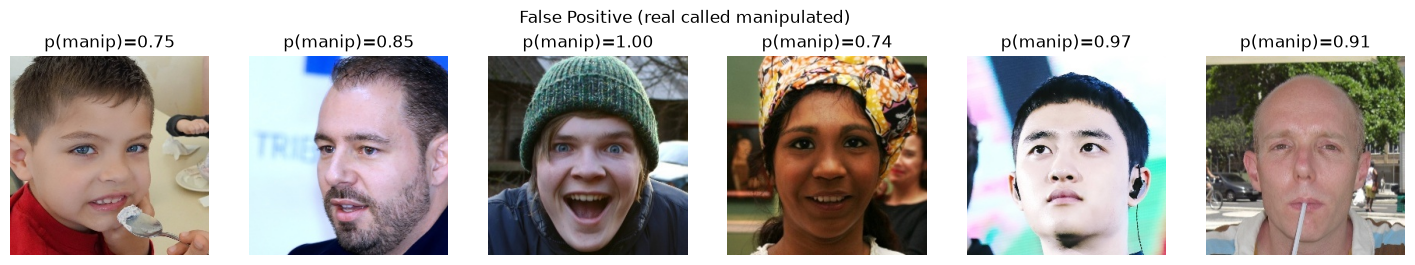

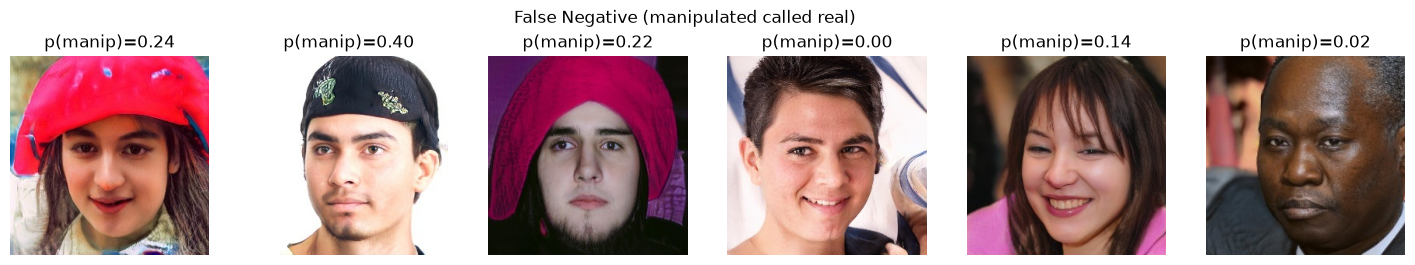

In [3]:
def show_grid(items, title, n=6):
    n = min(n, len(items))
    if n == 0:
        print(f'No examples for: {title}')
        return
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))
    if n == 1:
        axes = [axes]
    for ax, (path, prob) in zip(axes, items[:n]):
        img = Image.open(path).convert('RGB')
        ax.imshow(img)
        ax.set_title(f'p(manip)={prob:.2f}')
        ax.axis('off')
    fig.suptitle(title)
    plt.savefig(os.path.join(PLOTS_DIR, f'{title.lower().replace(" ", "_")}.png'))
    plt.show()

show_grid(buckets['correct_real'], 'Correct Real')
show_grid(buckets['correct_fake'], 'Correct Fake')
show_grid(buckets['false_positive'], 'False Positive (real called manipulated)')
show_grid(buckets['false_negative'], 'False Negative (manipulated called real)')

## Notes: actual findings from this run

Looked at all 29 false positives and all 10 false negatives (grids above).

**False positives (real photos called MANIPULATED)** -- the pattern here is
occlusion and unusual objects near the face: a spoon near the mouth, a straw,
hands, patterned headwear (beanie, headscarf), off-center crops with visible
background clutter. Several were called manipulated with very high confidence
(0.91-1.00) despite being real. My read: these objects/occlusions are probably
underrepresented in the training data (StyleGAN faces are almost always clean,
unobstructed, front-facing), so the model may have learned to associate
occlusion/clutter with "fake", which is a real dataset-bias issue, not noise.

**False negatives (StyleGAN-fake photos called REAL)** -- these are the
opposite: clean, well-lit, front-facing portraits with natural-looking skin
texture and no visible GAN artifacts. This matches expectations -- StyleGAN's
better outputs are genuinely hard to distinguish from real photos, even for
this trained model. This is a legitimate model limitation, not a bug.

**Takeaway for the README/limitations section**: this model appears to be
partly relying on framing/occlusion as a real-vs-fake signal rather than
purely photorealism cues, which would not generalize to real-world manipulated
photos that also have clean, unobstructed framing.